In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [2]:
url = r"C:\Users\phadt\OneDrive\Desktop\MLproj\Netflix clustering\netflix_titles.csv"
df = pd.read_csv(url)

In [32]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# feature selection 
df = df[['title', 'listed_in', 'rating', 'duration']]

# remove rows with missing values
df.dropna(inplace=True)

# Reset index 
df.reset_index(drop = True, inplace = True)


In [6]:
# feature engineering convert duration to numeric

# extract numeric part of duration 
df['duration_num'] = df['duration'].apply(lambda x: int(x.split()[0]))


In [7]:
# Encode rating (labelEncoder)
le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'])


In [10]:
# Encode Geners (multilablebinarizer)
# convert string into list

df['listed_in'] = df['listed_in'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
# apply multilabel binarizer
mlb = MultiLabelBinarizer()
gener_encoded = mlb.fit_transform(df['listed_in'])

# convert to dataframe
gener_df = pd.DataFrame(gener_encoded, columns = mlb.classes_)


In [13]:
# -------------------------
# GENRE ENCODING (CORRECT)
# -------------------------

from sklearn.preprocessing import MultiLabelBinarizer

# Ensure listed_in is a list
df['listed_in'] = df['listed_in'].apply(
    lambda x: x.split(', ') if isinstance(x, str) else x
)

# Apply MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['listed_in'])

# CREATE genre_df  (THIS WAS MISSING)
genre_df = pd.DataFrame(
    genre_encoded,
    columns=mlb.classes_,
    index=df.index
)

print("Genre DF created successfully")
print(genre_df.head())


Genre DF created successfully
    Anime Features   Children & Family Movies   Classic & Cult TV  \
0                0                          0                   0   
1                0                          0                   0   
2                0                          0                   0   
3                0                          0                   0   
4                0                          0                   0   

    Classic Movies   Comedies   Crime TV Shows   Cult Movies   Documentaries  \
0                0          0                0             0               0   
1                0          0                0             0               0   
2                0          0                0             0               0   
3                0          0                0             0               0   
4                0          0                0             0               0   

    Docuseries   Dramas  ...  Sports Movies  Stand-Up Comedy  \
0         

In [14]:
# combine features safe

final_features = pd.concat( [gener_df, df[['rating_encoded', 'duration_num']]], axis = 1)
print(final_features.head())

    Anime Features   Children & Family Movies   Classic & Cult TV  \
0                0                          0                   0   
1                0                          0                   0   
2                0                          0                   0   
3                0                          0                   0   
4                0                          0                   0   

    Classic Movies   Comedies   Crime TV Shows   Cult Movies   Documentaries  \
0                0          0                0             0               0   
1                0          0                0             0               0   
2                0          0                0             0               0   
3                0          0                0             0               0   
4                0          0                0             0               0   

    Docuseries   Dramas  ...  Stand-Up Comedy & Talk Shows  \
0            0        0  ...              

In [15]:
# train test split (conceptual )

from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(final_features, test_size =0.2, random_state = 42)

In [16]:
# feature standardizatioon 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [17]:
# apply clustering algorithms 
kmeans = KMeans(n_clusters= 4, random_state =42)
kmeans_labels = kmeans.fit_predict(X_train_scaled)

print("KMeans Silhouette Score:", silhouette_score(X_train_scaled, kmeans_labels))

KMeans Silhouette Score: 0.20233156994689977


In [19]:
# agglomerative clustering 
agglo = AgglomerativeClustering(n_clusters=4)
agglo_labels = agglo.fit_predict(X_train_scaled)

print("Agglomerative Silhouette Score:", silhouette_score(X_train_scaled, agglo_labels))

Agglomerative Silhouette Score: 0.06373199972287738


In [20]:
# DBSCAN Clustering 
dbscan = DBSCAN(eps = 1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_train_scaled)

# Ignore noise for silhouette score
mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
    print("DBSCAN Silhouette Score:", silhouette_score(X_train_scaled[mask], dbscan_labels[mask]))
else:
    print("DBSCAN Silhouette Score: Not applicable")

DBSCAN Silhouette Score: 0.7362269591024416


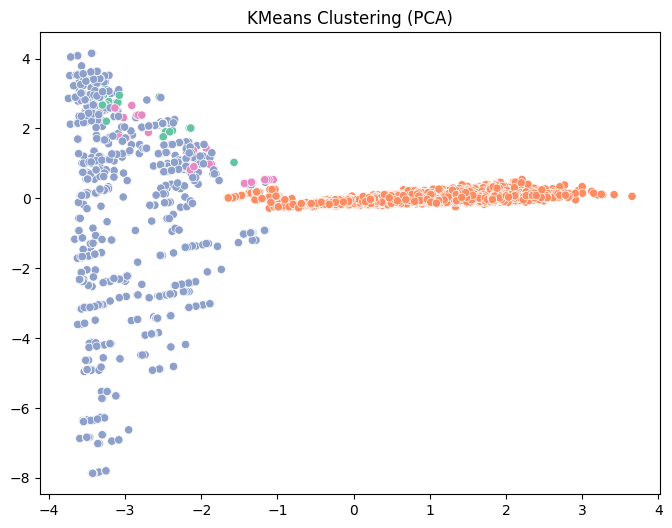

In [21]:
# Visualization using PCA 
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_train_scaled)

plt.figure(figsize = (8,6))
sns.scatterplot(x=pca_data[:,0],
    y=pca_data[:,1],
    hue=kmeans_labels,
    palette='Set2',
    legend=False
)
plt.title("KMeans Clustering (PCA)")
plt.show()

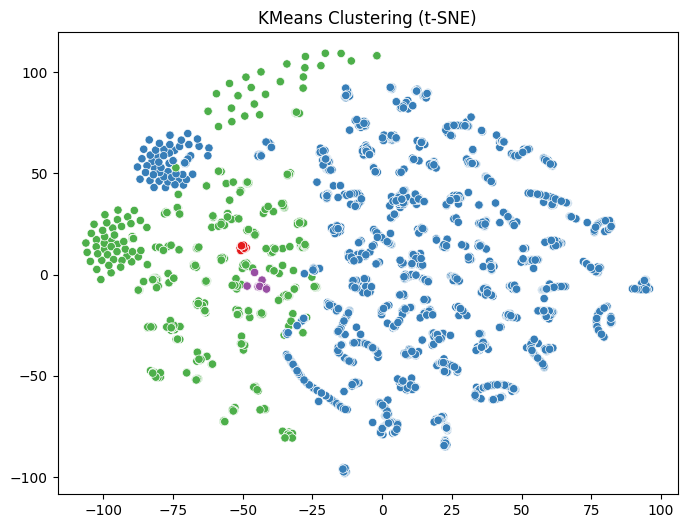

In [22]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_data = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=tsne_data[:,0],
    y=tsne_data[:,1],
    hue=kmeans_labels,
    palette='Set1',
    legend=False
)
plt.title("KMeans Clustering (t-SNE)")
plt.show()


In [23]:
df_train = df.iloc[X_train.index].copy()
df_train['cluster_kmeans'] = kmeans_labels
df_train['cluster_agglo'] = agglo_labels
df_train['cluster_dbscan'] = dbscan_labels

print(df_train[['title', 'cluster_kmeans']].head())


                               title  cluster_kmeans
2067  Fate/Grand Order -First Order-               1
4982     In This Corner of the World               1
8648            Unaccompanied Minors               1
1643                        The Call               1
106                           Bunk'd               2


In [24]:
import pickle

model_artifacts = {
    "scaler": scaler,
    "mlb": mlb,
    "label_encoder": le,
    "kmeans": kmeans,
    "pca": pca,
    "feature_columns": final_features.columns.tolist()
}

with open("netflix_clustering_model.pkl", "wb") as f:
    pickle.dump(model_artifacts, f)

print("Pickle file saved successfully!")


Pickle file saved successfully!
